In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [59]:
data = pd.read_csv('/content/walmart_cleaned.csv')
data.sample(3)

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
50586,50781,6,2010-07-30,0,71.0,6192.92,81.37,2.640,0.00,0.00,0.00,0.00,0.00,212.894485,6.973,3,202505
209998,210817,22,2010-11-26,1,45.0,20.94,44.61,3.070,0.00,0.00,0.00,0.00,0.00,136.689571,8.572,2,119557
55960,56155,6,2012-01-06,0,58.0,1765.00,50.82,3.157,3220.17,32056.43,108.24,985.76,6650.63,221.308802,6.132,3,202505


In [60]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.sample(3)

,Store,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
Date,,,,,,,,,,,,,,,
2011-09-30,19,0,23.0,23015.38,64.99,3.858,0.0,0.0,0.0,0.0,0.0,136.419500,7.806,3,203819
2010-12-17,31,0,81.0,25067.35,48.63,2.869,0.0,0.0,0.0,0.0,0.0,211.064546,8.163,3,203750
2011-07-01,38,0,94.0,21870.67,89.85,3.842,0.0,0.0,0.0,0.0,0.0,129.089400,13.503,1,39690


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 421570 entries, 2010-02-05 to 2012-10-26
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   IsHoliday     421570 non-null  int64  
 2   Dept          421570 non-null  float64
 3   Weekly_Sales  421570 non-null  float64
 4   Temperature   421570 non-null  float64
 5   Fuel_Price    421570 non-null  float64
 6   MarkDown1     421570 non-null  float64
 7   MarkDown2     421570 non-null  float64
 8   MarkDown3     421570 non-null  float64
 9   MarkDown4     421570 non-null  float64
 10  MarkDown5     421570 non-null  float64
 11  CPI           421570 non-null  float64
 12  Unemployment  421570 non-null  float64
 13  Type          421570 non-null  int64  
 14  Size          421570 non-null  int64  
dtypes: float64(11), int64(4)
memory usage: 51.5 MB


In [62]:
data.shape

(421570, 15)

In [63]:
data.describe()

,Store,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,0.070358,44.260317,15981.258123,60.090059,3.361027,2590.074819,879.974298,468.087665,1083.132268,1662.772385,171.201947,7.960289,2.410088,136727.915739
std,12.785297,0.255750,30.492054,22711.183519,18.447931,0.458515,6052.385934,5084.538801,5528.873453,3894.529945,4207.629321,39.159276,1.863296,0.666337,60980.583328
min,1.000000,0.000000,1.000000,-4988.940000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,1.000000,34875.000000
25%,11.000000,0.000000,18.000000,2079.650000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,2.000000,93638.000000
50%,22.000000,0.000000,37.000000,7612.030000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,3.000000,140167.000000
75%,33.000000,0.000000,74.000000,20205.852500,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,3.000000,202505.000000
max,45.000000,1.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,3.000000,219622.000000


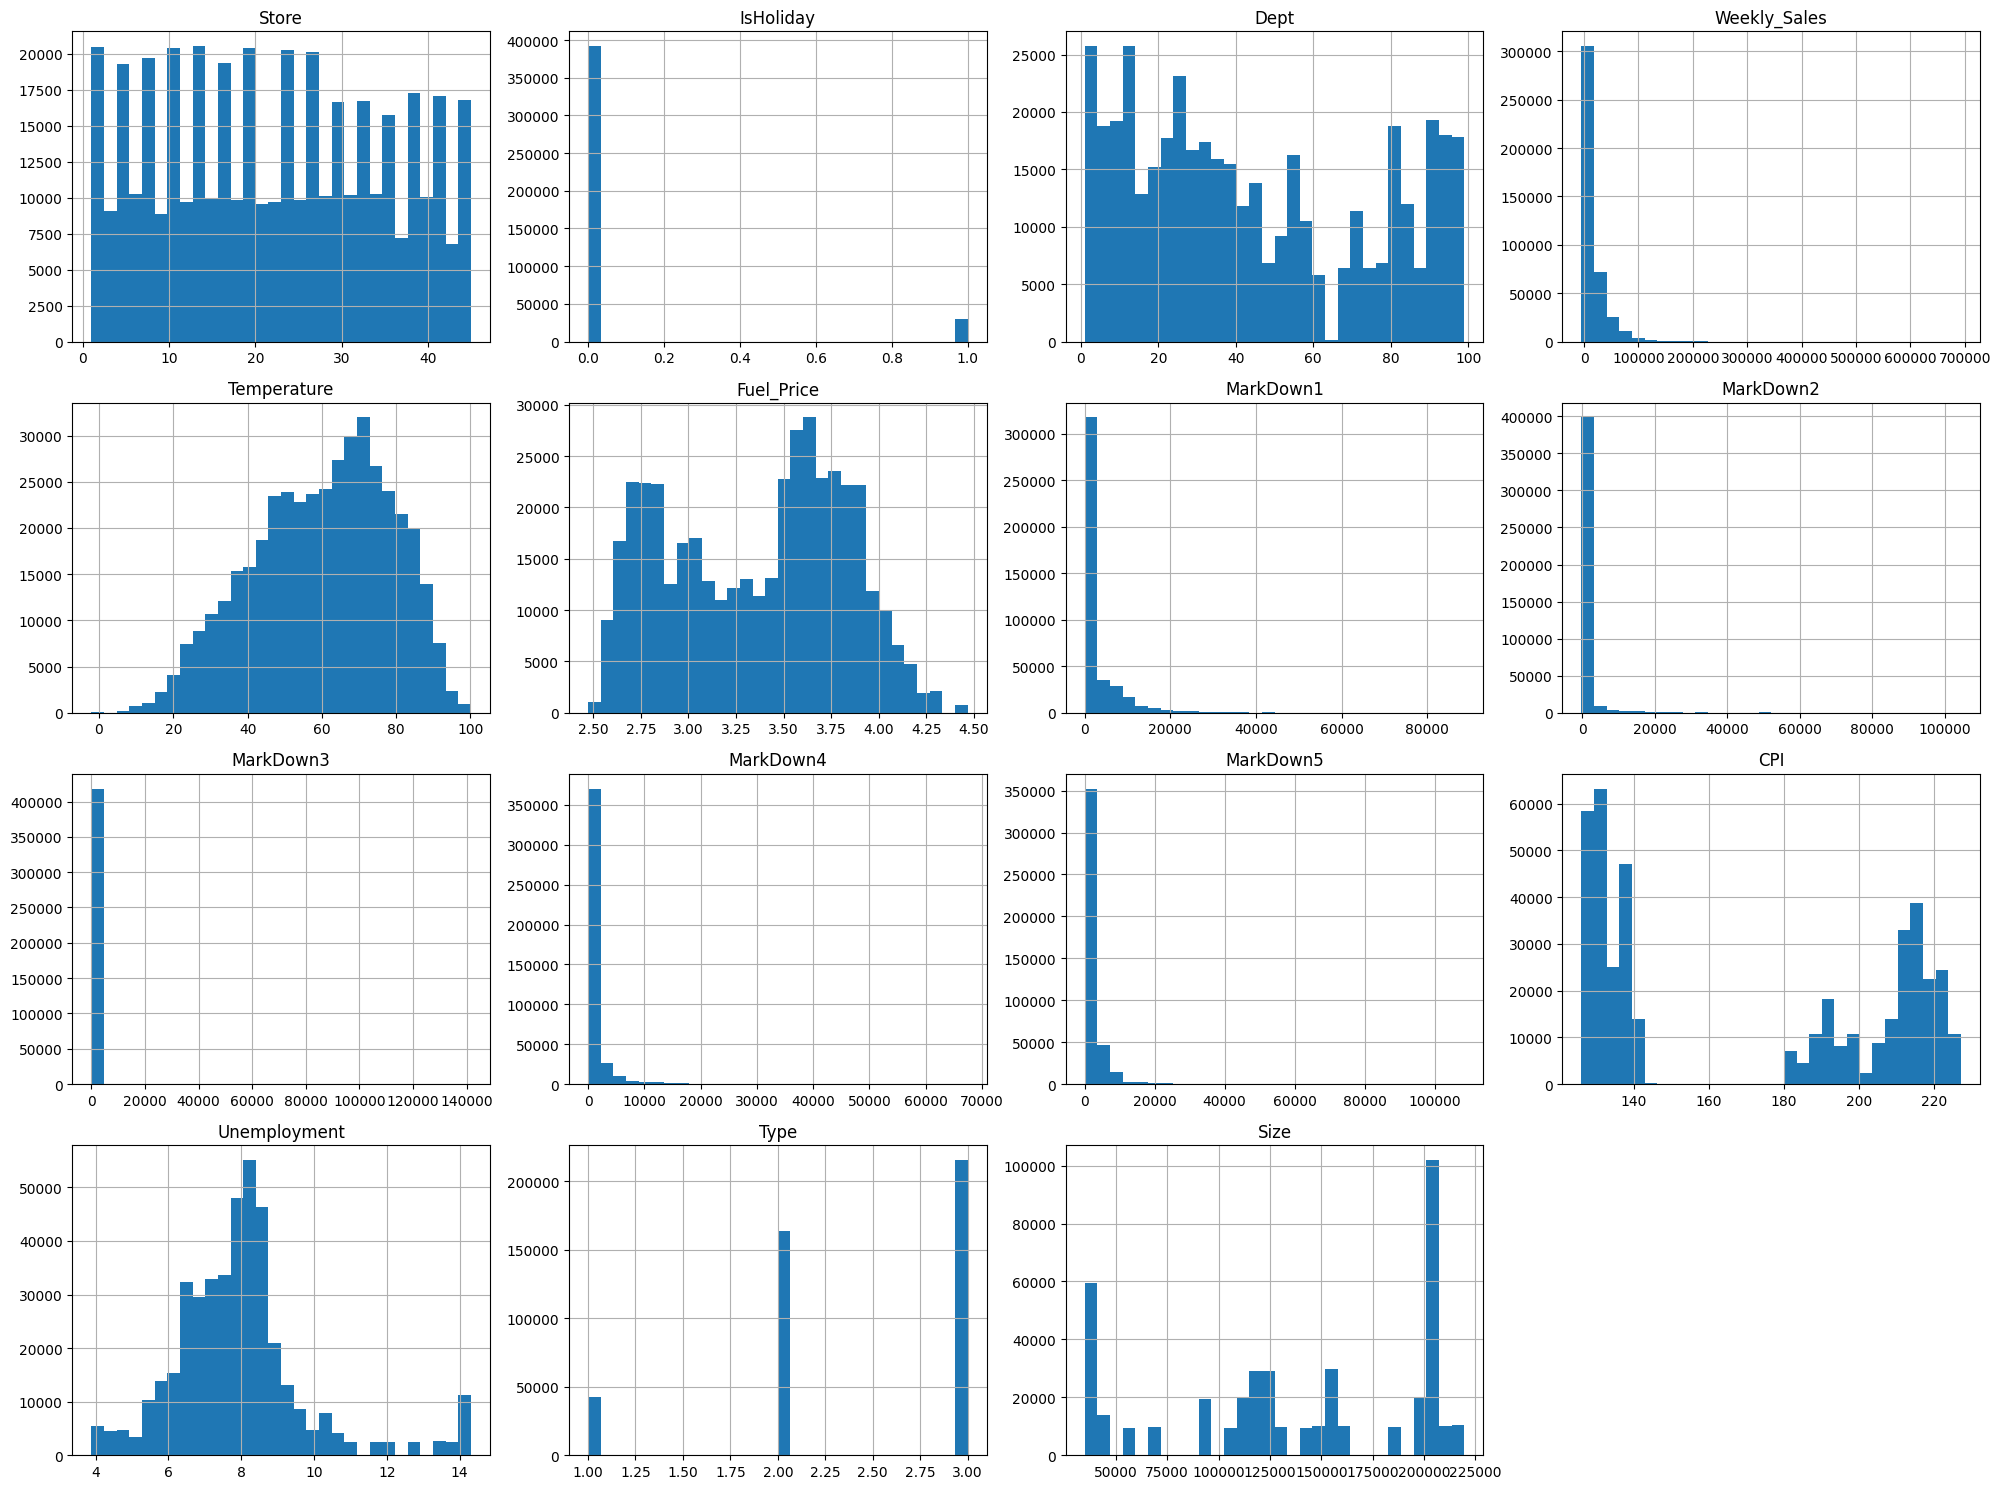

In [64]:
data.hist(bins=30, figsize=(20,15))
plt.tight_layout()
plt.show()

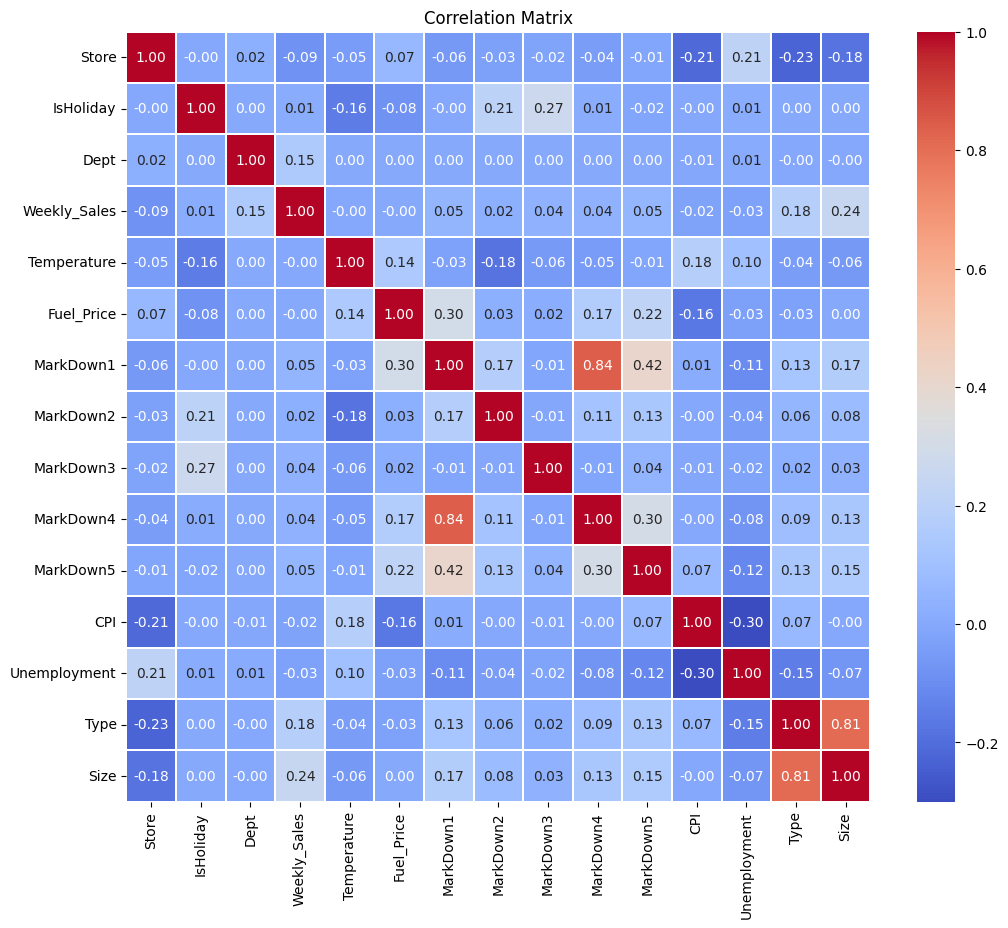

In [65]:
corr_matrix = data.corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.1)
plt.title('Correlation Matrix')
plt.show()

In [66]:
from scipy.stats import zscore



# Calculate the Z-scores of the 'Weekly_Sales' column
data['Sales_Zscore'] = zscore(data['Weekly_Sales'])

# Define a threshold
threshold = 3

# Identify outliers
outliers = data[abs(data['Sales_Zscore']) > threshold]

# Number of outliers
num_outliers = len(outliers)

num_outliers

8848

In [67]:
data = data[abs(data['Sales_Zscore']) <= threshold]
data

,Store,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Sales_Zscore
Date,,,,,,,,,,,,,,,,
2010-02-05,1,0,1.0,24924.50,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,3,151315,0.393782
2010-02-05,1,0,26.0,11737.12,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,3,151315,-0.186875
2010-02-05,1,0,17.0,13223.76,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,3,151315,-0.121416
2010-02-05,1,0,45.0,37.44,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,3,151315,-0.702026
2010-02-05,1,0,28.0,1085.29,42.31,2.572,0.00,0.00,0.0,0.00,0.00,211.096358,8.106,3,151315,-0.655888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-10-26,45,0,13.0,26240.14,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,2,118221,0.451711
2012-10-26,45,0,16.0,2660.02,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,2,118221,-0.586550
2012-10-26,45,0,32.0,4131.54,58.85,3.882,4018.91,58.08,100.0,211.94,858.33,192.308899,8.667,2,118221,-0.521758


In [68]:
# Feature engineering
data['Month'] = data.index.month
data['Size_Type'] = data['Size'] * data['Type']
features = ['Size', 'Dept', 'IsHoliday', 'Type', 'CPI', 'Unemployment', 'Month', 'Size_Type']
target = 'Weekly_Sales'

In [69]:
X = data[features]
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from numpy._core import numeric
numeric_features = ['Size', 'Dept', 'CPI', 'Unemployment', 'Month', 'Size_Type']
categorical_features = ['IsHoliday', 'Type']

In [71]:
processing = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'Bagging': BaggingRegressor(),
    'Extra Trees': ExtraTreesRegressor(),

}

results = {}

for name,regressor in models.items():
  model = Pipeline([
      ('processing', processing),
      ('regressor', regressor)
  ])
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  results[name] = {'MSE': mse, 'R2': r2}

  print(f'{name} MSE: {mse:.2f} and R2: {r2:.2f}')

best_model = min(results, key=lambda x: results[x]['MSE'])
print(f'The best model is {best_model} with MSE: {results[best_model]["MSE"]:.2f} and R2: {results[best_model]["R2"]:.2f}')

Linear Regression MSE: 267074102.25 and R2: 0.06
Random Forest MSE: 9429229.68 and R2: 0.97
Gradient Boosting MSE: 84201924.73 and R2: 0.70
AdaBoost MSE: 210278951.66 and R2: 0.26
Bagging MSE: 10062428.70 and R2: 0.96
Extra Trees MSE: 10869981.41 and R2: 0.96
The best model is Random Forest with MSE: 9429229.68 and R2: 0.96


In [74]:
model = Pipeline([
      ('processing', processing),
      ('regressor', models[best_model])
  ])

# Perform cross-validation for MSE
cv_mse = -cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
).mean()

# Perform cross-validation for R2 score
cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
).mean()
print(f'📊 The best model is {best_model} with CROSS-VALIDATION:')
print(f"\nMSE: {cv_mse:.4f}")
print(f"\nR² SCORE: {cv_r2:.4f}")






📊 The best model is Random Forest with CROSS-VALIDATION:

MSE: 9826511.1398

R² SCORE: 0.9655
